In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os

In [2]:
# ------------------------------------------------------------
# 1. Параметры
# ------------------------------------------------------------
DATA_DIR = r'C:\Users\gabde\real_and_synth'   # путь к данным
IMG_HEIGHT, IMG_WIDTH = 128, 128                 # размер входных изображений
BATCH_SIZE = 32
EPOCHS = 30                                      # количество эпох (можно увеличить)
VALIDATION_SPLIT = 0.2                           # доля данных для валидации

# Папка для сохранения чекпоинтов
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [3]:
# ------------------------------------------------------------
# 2. Аугментация и генераторы
# ------------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

# Генератор для обучения
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),   # все изображения ресайзятся сюда
    batch_size=BATCH_SIZE,
    class_mode='categorical',              # для 3+ классов
    subset='training',
    shuffle=True
)

# Генератор для валидации
validation_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"Найдено классов: {num_classes}")
print(f"Имена классов: {train_generator.class_indices}")

Found 1920 images belonging to 3 classes.
Found 480 images belonging to 3 classes.
Найдено классов: 3
Имена классов: {'Anthracnose_r&s': 0, 'Downy Mildew': 1, 'Fresh Leaf': 2}


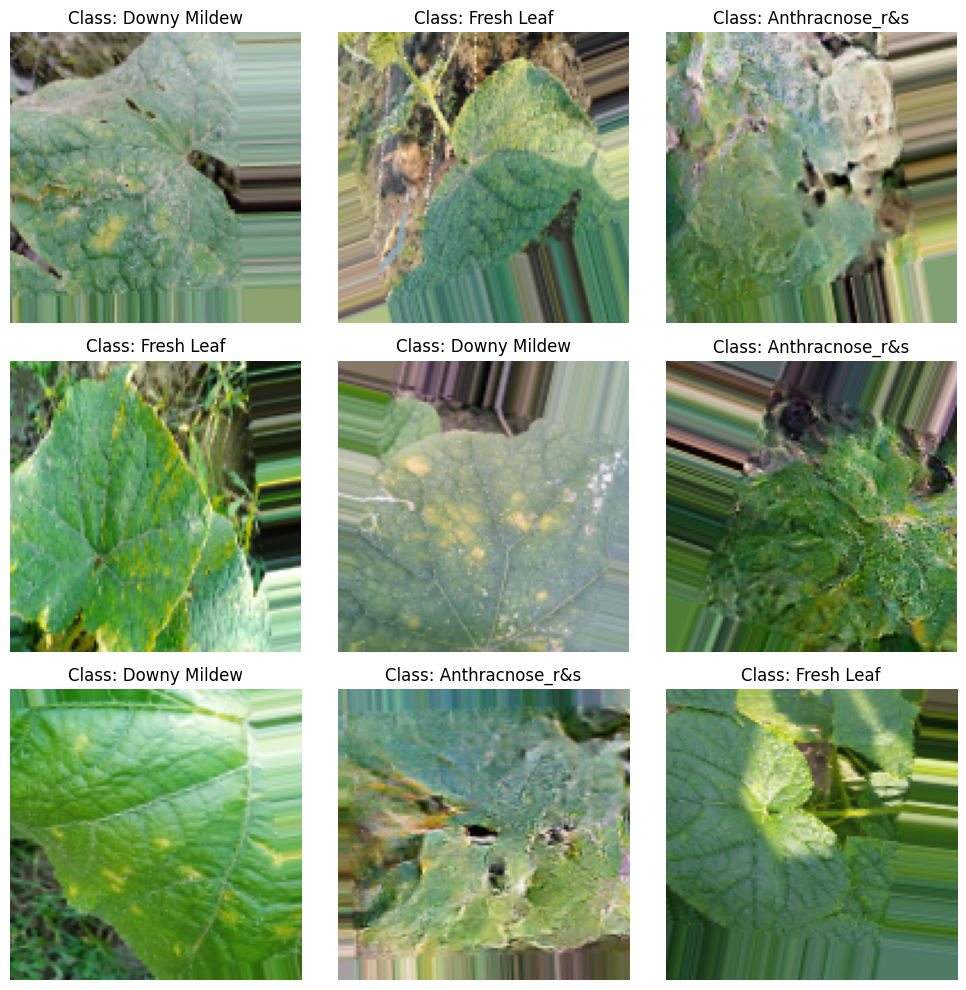

In [4]:
# ------------------------------------------------------------
# Визуализация нескольких изображений из train_generator
# ------------------------------------------------------------
# Получаем один батч изображений и меток
images, labels = next(train_generator)  # берём первый батч

# Количество изображений для отображения (квадратная сетка)
num_display = 9
plt.figure(figsize=(10, 10))

# Индексы классов для подписей (обратное отображение)
class_labels = {v: k for k, v in train_generator.class_indices.items()}

for i in range(num_display):
    plt.subplot(3, 3, i + 1)
    # Изображения уже нормализованы (0..1), можно показывать
    plt.imshow(images[i])
    # Получаем предсказанный класс (argmax) и реальный
    true_label = np.argmax(labels[i])
    plt.title(f"Class: {class_labels[true_label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# ------------------------------------------------------------
# 3. Модель MobileNetV2
# ------------------------------------------------------------
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # заморозка на первом этапе

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# ------------------------------------------------------------
# 4. Обучение
# ------------------------------------------------------------

# Сохранять только лучшую модель по val_accuracy
checkpoint = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'best_model_c.h5'),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Остановиться, если val_accuracy не улучшается в течение 5 эпох
early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,   # после остановки восстановит лучшие веса
    verbose=1
)

callbacks = [checkpoint, early_stop]

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.5953 - loss: 0.9413
Epoch 1: val_accuracy improved from None to 0.68333, saving model to checkpoints\best_model_c.h5



Epoch 1: finished saving model to checkpoints\best_model_c.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 599ms/step - accuracy: 0.7250 - loss: 0.6509 - val_accuracy: 0.6833 - val_loss: 0.7855
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8544 - loss: 0.3887
Epoch 2: val_accuracy improved from 0.68333 to 0.73958, saving model to checkpoints\best_model_c.h5



Epoch 2: finished saving model to checkpoints\best_model_c.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 597ms/step - accuracy: 0.8635 - loss: 0.3724 - val_accuracy: 0.7396 - val_loss: 0.6800
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8748 - loss: 0.3105
Epoch 3: val_accuracy did not improve from 0.73958
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 576ms/step - accuracy: 0.8813 - loss: 0.3035 - val_accuracy: 0.6687 - val_loss: 0.7907
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8837 - loss: 0.2906
Epoch 4: val_accuracy improved from 0.73958 to 0.78958, saving model to checkpoints\best_model_c.h5



Epoch 4: finished saving model to checkpoints\best_model_c.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 608ms/step - accuracy: 0.8911 - loss: 0.2857 - val_accuracy: 0.7896 - val_loss: 0.5688
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.9022 - loss: 0.2622
Epoch 5: val_accuracy improved from 0.78958 to 0.79375, saving model to checkpoints\best_model_c.h5



Epoch 5: finished saving model to checkpoints\best_model_c.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 37s 622ms/step - accuracy: 0.8969 - loss: 0.2652 - val_accuracy: 0.7937 - val_loss: 0.5524
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9070 - loss: 0.2429
Epoch 6: val_accuracy did not improve from 0.79375
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 595ms/step - accuracy: 0.9141 - loss: 0.2320 - val_accuracy: 0.7104 - val_loss: 0.8807
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9053 - loss: 0.2467
Epoch 7: val_accuracy did not improve from 0.79375
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 581ms/step - accuracy: 0.9099 - loss: 0.2368 - val_accuracy: 0.7563 - val_loss: 0.6788
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9277 - loss: 0.1925
Epoch 8: val_accuracy did not improve from 0.79375
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 582ms/step - accuracy: 0.9229 - loss: 0.2036 - val_accuracy: 0.7708 - val_loss: 0.6896
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - 

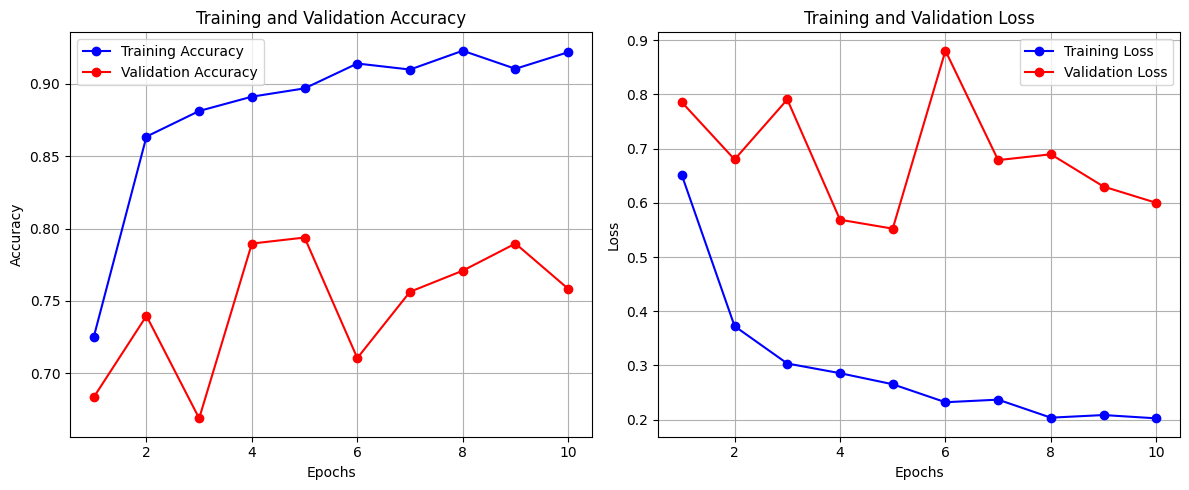

In [7]:
# ------------------------------------------------------------
# Графики обучения
# ------------------------------------------------------------
# Извлекаем метрики из истории
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Создаём фигуру с двумя подграфиками
plt.figure(figsize=(12, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График потерь
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'bo-', label='Training Loss')
plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()